# Notebook 03: Exploration
#
 Before running formal statistical tests we explore the score
 distributions visually. This notebook answers three questions:
1. Does the model discriminate between positive and negative cases?
 2. Are the confidence scores visually miscalibrated?
 3. What does the calibration gap look like across confidence bins?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"] = 11
import os

# ── Constants ────────────────────────────────────────────────────────────────
N_BINS  = 10
ALPHA   = 0.05
DISEASE = "Effusion"

# Load the master scores file
df = pd.read_csv("../data/scores.csv")

# Basic validation
assert df["confidence_score"].between(0,1).all(), "Scores must be in [0,1]"
assert df["ground_truth"].isin([0,1]).all(), "Labels must be 0 or 1"
assert df.notna().all().all(), "No NaN values allowed"

print("=== DATA LOADED ===")
print(f"Total samples:    {len(df):,}")
print(f"Positive cases:   {df['ground_truth'].sum():,} ({df['ground_truth'].mean()*100:.2f}%)")
print(f"Negative cases:   {(df['ground_truth']==0).sum():,}")
print(f"Score range:      [{df['confidence_score'].min():.4f}, {df['confidence_score'].max():.4f}]")
print(f"Mean confidence:  {df['confidence_score'].mean():.4f}")
print(f"True prevalence:  {df['ground_truth'].mean():.4f}")
print(f"Calibration gap:  {df['confidence_score'].mean() - df['ground_truth'].mean():+.4f}")

=== DATA LOADED ===
Total samples:    10,000
Positive cases:   895 (8.95%)
Negative cases:   9,105
Score range:      [0.0001, 0.9782]
Mean confidence:  0.2655
True prevalence:  0.0895
Calibration gap:  +0.1760


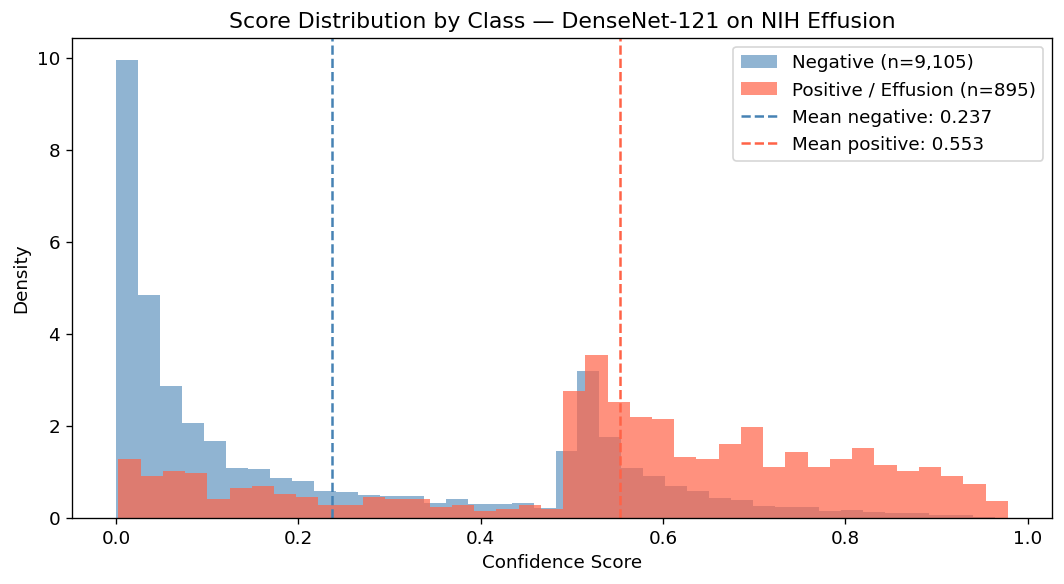

Saved: outputs/plots/01_score_distribution.png


In [2]:
# ── Plot 1: Score Distribution by Class ──────────────────────────────────────
pos_scores = df[df["ground_truth"]==1]["confidence_score"]
neg_scores = df[df["ground_truth"]==0]["confidence_score"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(neg_scores, bins=40, alpha=0.6, color="steelblue",
        label=f"Negative (n={len(neg_scores):,})", density=True)
ax.hist(pos_scores, bins=40, alpha=0.7, color="tomato",
        label=f"Positive / {DISEASE} (n={len(pos_scores):,})", density=True)
ax.axvline(neg_scores.mean(), color="steelblue", linestyle="--",
           linewidth=1.5, label=f"Mean negative: {neg_scores.mean():.3f}")
ax.axvline(pos_scores.mean(), color="tomato", linestyle="--",
           linewidth=1.5, label=f"Mean positive: {pos_scores.mean():.3f}")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Density")
ax.set_title(f"Score Distribution by Class — DenseNet-121 on NIH {DISEASE}")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/01_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/01_score_distribution.png")

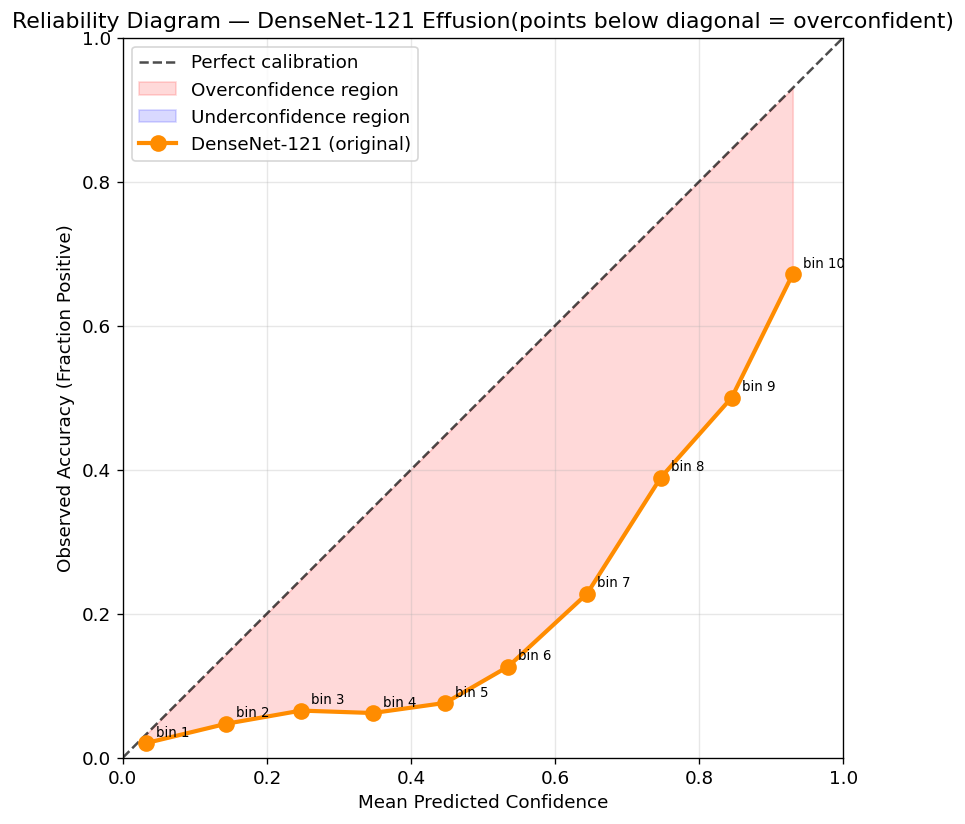

Saved: outputs/plots/02_reliability_diagram_original.png


In [3]:
# ── Plot 2: Reliability Diagram ───────────────────────────────────────────────
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    df["ground_truth"],
    df["confidence_score"],
    n_bins=N_BINS,
    strategy="uniform"
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.7, label="Perfect calibration")
ax.fill_between(prob_pred, prob_true, prob_pred,
                where=(prob_pred > prob_true),
                alpha=0.15, color="red", label="Overconfidence region")
ax.fill_between(prob_pred, prob_true, prob_pred,
                where=(prob_pred <= prob_true),
                alpha=0.15, color="blue", label="Underconfidence region")
ax.plot(prob_pred, prob_true, "o-", color="darkorange",
        linewidth=2.5, markersize=9, label="DenseNet-121 (original)")
for i, (x, y) in enumerate(zip(prob_pred, prob_true)):
    ax.annotate(f"bin {i+1}", (x, y),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean Predicted Confidence")
ax.set_ylabel("Observed Accuracy (Fraction Positive)")
ax.set_title(f"Reliability Diagram — DenseNet-121 {DISEASE}(points below diagonal = overconfident)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/plots/02_reliability_diagram_original.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/02_reliability_diagram_original.png")

In [4]:
# ── Compute ECE and MCE ───────────────────────────────────────────────────────
def compute_ece(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error.
    Args:
        y_true: array of binary ground truth labels (0 or 1)
        y_prob: array of predicted probabilities in [0,1]
        n_bins: number of equal-width bins (default 10)
    Returns:
        ece: float, weighted average calibration error across bins
    """
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n_total = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        n_bin      = mask.sum()
        accuracy   = y_true[mask].mean()
        confidence = y_prob[mask].mean()
        ece += (n_bin / n_total) * abs(accuracy - confidence)
    return ece

def compute_mce(y_true, y_prob, n_bins=10):
    """
    Compute Maximum Calibration Error — worst single bin gap.
    Args:
        y_true: array of binary ground truth labels
        y_prob: array of predicted probabilities
        n_bins: number of bins
    Returns:
        mce: float, maximum absolute gap across all bins
    """
    bins = np.linspace(0, 1, n_bins + 1)
    max_gap = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() < 5:
            continue
        accuracy   = y_true[mask].mean()
        confidence = y_prob[mask].mean()
        gap        = abs(accuracy - confidence)
        if gap > max_gap:
            max_gap = gap
    return max_gap

y_true = df["ground_truth"].values
y_prob = df["confidence_score"].values

ece = compute_ece(y_true, y_prob, n_bins=N_BINS)
mce = compute_mce(y_true, y_prob, n_bins=N_BINS)

print("=== CALIBRATION METRICS ===")
print(f"ECE (Expected Calibration Error): {ece:.4f}")
print(f"MCE (Maximum Calibration Error):  {mce:.4f}")
print()
if ece > 0.10:
    print("ECE interpretation: SEVERE miscalibration (ECE > 0.10)")
elif ece > 0.05:
    print("ECE interpretation: MODERATE miscalibration (ECE 0.05-0.10)")
else:
    print("ECE interpretation: MILD miscalibration (ECE < 0.05)")
print()
print(f"Clinical meaning: When the model says it is confident,")
print(f"it is off by {ece*100:.1f} percentage points on average.")
print(f"Worst single bin gap: {mce*100:.1f} percentage points.")

=== CALIBRATION METRICS ===
ECE (Expected Calibration Error): 0.1760
MCE (Maximum Calibration Error):  0.4167

ECE interpretation: SEVERE miscalibration (ECE > 0.10)

Clinical meaning: When the model says it is confident,
it is off by 17.6 percentage points on average.
Worst single bin gap: 41.7 percentage points.


In [5]:
# ── Bin-level breakdown table ─────────────────────────────────────────────────
bins = np.linspace(0, 1, N_BINS + 1)
rows = []

for i in range(N_BINS):
    mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
    n_bin = mask.sum()
    if n_bin == 0:
        continue
    accuracy   = y_true[mask].mean()
    confidence = y_prob[mask].mean()
    gap        = accuracy - confidence
    rows.append({
        "Bin":        f"{bins[i]:.1f}–{bins[i+1]:.1f}",
        "N samples":  n_bin,
        "Mean conf":  round(confidence, 4),
        "Obs. acc":   round(accuracy, 4),
        "Gap":        round(gap, 4),
        "Direction":  "overconfident" if gap < -0.01 else
                      "underconfident" if gap > 0.01 else "calibrated"
    })

bin_df = pd.DataFrame(rows)
print("=== BIN-LEVEL CALIBRATION BREAKDOWN ===")
print(bin_df.to_string(index=False))
print()
print(f"Bins showing overconfidence: {(bin_df['Gap'] < -0.01).sum()}")
print(f"Bins showing underconfidence: {(bin_df['Gap'] > 0.01).sum()}")
print(f"Bins approximately calibrated: {(bin_df['Gap'].abs() <= 0.01).sum()}")

=== BIN-LEVEL CALIBRATION BREAKDOWN ===
    Bin  N samples  Mean conf  Obs. acc     Gap     Direction
0.0–0.1       4482     0.0327    0.0203 -0.0124 overconfident
0.1–0.2       1061     0.1438    0.0471 -0.0966 overconfident
0.2–0.3        566     0.2474    0.0654 -0.1820 overconfident
0.3–0.4        371     0.3471    0.0620 -0.2851 overconfident
0.4–0.5        276     0.4477    0.0761 -0.3716 overconfident
0.5–0.6       2030     0.5351    0.1266 -0.4085 overconfident
0.6–0.7        615     0.6443    0.2276 -0.4167 overconfident
0.7–0.8        319     0.7466    0.3887 -0.3579 overconfident
0.8–0.9        210     0.8452    0.5000 -0.3452 overconfident
0.9–1.0         70     0.9299    0.6714 -0.2585 overconfident

Bins showing overconfidence: 10
Bins showing underconfidence: 0
Bins approximately calibrated: 0
